Import Libraies

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

Data Loading

In [3]:
df_events = pd.read_csv('D:/Data Science Bootcamp 3.0/InterShip/resources_1/resources_1/datasets/fact_events.csv')
df_events.head(3)

,event_id,store_id,campaign_id,product_code,base_price(before_promo),quantity_sold(before_promo),promo_type,base_price(after_promo),quantity_sold(after_promo)
0,8481be,STCHE-1,CAMP_DIW_01,P04,290,327.0,25% OFF,217,287
1,20618e,STCHE-3,CAMP_SAN_01,P04,370,379.0,BOGOF,185,1622
2,f30579,STBLR-9,CAMP_DIW_01,P02,860,337.0,33% OFF,576,488


In [4]:
#Check for and remove duplicate rows in the events dataframe
#print("Number of duplicate rows:", df_events.duplicated().sum())

duplicate_count = df_events.duplicated(
    subset=['store_id', 'campaign_id', 'product_code']
).sum()

print("Number of duplicate rows:",duplicate_count)


# Display duplicate rows
# keep=False → marks all occurrences of duplicated rows as True

# Count duplicate rows before removing them
print("Duplicate Data")
duplicate_data = df_events[df_events.duplicated(subset=['store_id', 'campaign_id', 'product_code'],keep=False)]
print(duplicate_data)

Number of duplicate rows: 10
Duplicate Data
      event_id store_id  campaign_id product_code  base_price(before_promo)  \
40      46d57b  STBLR-9  CAMP_DIW_01          P13                       350   
74      46d57b  STBLR-9  CAMP_DIW_01          P13                       350   
126     4ad12b  STBLR-4  CAMP_DIW_01          P15                      3000   
136     f6aa36  STVSK-3  CAMP_DIW_01          P06                       415   
333     0491f4  STVSK-2  CAMP_DIW_01          P11                       190   
395   6.24E+11  STMLR-0  CAMP_SAN_01          P03                       200   
410     f6aa36  STVSK-3  CAMP_DIW_01          P06                       415   
423     491ff2  STVJD-1  CAMP_SAN_01          P12                        62   
541   6.24E+11  STMLR-0  CAMP_SAN_01          P03                       200   
703     0f8686  STVSK-0  CAMP_SAN_01          P07                       300   
738     5c7b20  STCBE-4  CAMP_DIW_01          P05                        55   
759     

In [5]:
# Remove duplicates, keeping the first occurrence

df_events = df_events.drop_duplicates(subset=['store_id', 'campaign_id', 'product_code'],keep='first')

print("How many duplicate rows were removed?", duplicate_count)

How many duplicate rows were removed? 10


In [6]:
# How many cities have more than 5 stores?

df_store = pd.read_csv('D:/Data Science Bootcamp 3.0/InterShip/resources_1/resources_1/datasets/dim_stores.csv')
df_store.head()
df_store.shape
print(df_store.columns)

store_count = df_store.groupby('city')['store_id'].count()

result = (store_count > 5).sum()

print("How many cities have more than 5 stores? :- ",result)
# City Name with store count
print("City Name:- ", df_store.groupby('city')['store_id'].count())

Index(['store_id', 'city'], dtype='str')
How many cities have more than 5 stores? :-  3
City Name:-  city
Bengaluru        10
Chennai           8
Coimbatore        5
Hyderabad         7
Madurai           4
Mangalore         3
Mysuru            4
Trivandrum        2
Vijayawada        2
Visakhapatnam     5
Name: store_id, dtype: int64


In [7]:
# How many missing values were filled, and what is the median used for imputation?

missing_values = df_events.isnull().sum()
print("Missing values :- ",missing_values)

median_base_price = df_events['quantity_sold(before_promo)'].median()
print("Median of quantity_sold (before_promo) :- ",median_base_price)

df_events['quantity_sold(before_promo)'] = df_events['quantity_sold(before_promo)'].fillna(median_base_price,inplace= True)



Missing values :-  event_id                        0
store_id                        0
campaign_id                     0
product_code                    0
base_price(before_promo)        0
quantity_sold(before_promo)    20
promo_type                      0
base_price(after_promo)         0
quantity_sold(after_promo)      0
dtype: int64
Median of quantity_sold (before_promo) :-  78.0


C:\Users\Admin\AppData\Local\Temp\ipykernel_11312\3181418152.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_events['quantity_sold(before_promo)'] = df_events['quantity_sold(before_promo)'].fillna(median_base_price,inplace= True)


In [8]:
missing_values = df_events.isnull().sum()
print("Missing values :- ",missing_values)

Missing values :-  event_id                       0
store_id                       0
campaign_id                    0
product_code                   0
base_price(before_promo)       0
quantity_sold(before_promo)    0
promo_type                     0
base_price(after_promo)        0
quantity_sold(after_promo)     0
dtype: int64


In [9]:
df_dim_products = pd.read_csv('D:/Data Science Bootcamp 3.0/InterShip/resources_1/resources_1/datasets/dim_products.csv')
df_dim_products.head(15)

,product_code,product_name,category
0,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples
1,P02,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples
2,P03,Atliq_Suflower_Oil (1L),Grocery & Staples
3,P04,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples
4,P05,Atliq_Scrub_Sponge_For_Dishwash,Home Care
5,P06,Atliq_Fusion_Container_Set_of_3,Home Care
6,P09,Atliq_Body_Milk_Nourishing_Lotion (120ML),Personal Care
7,P10,Atliq_Cream_Beauty_Bathing_Soap (125GM),Personal Care
8,P13,Atliq_High_Glo_15W_LED_Bulb,Home Appliances
9,P14,Atliq_waterproof_Immersion_Rod,Home Appliances


In [10]:
#Identify the product category with the lowest base price before the promotion.


df_dim_products = pd.read_csv('D:/Data Science Bootcamp 3.0/InterShip/resources_1/resources_1/datasets/dim_products.csv')
df_dim_products.head()

df_events_dim_products = pd.merge(df_events, df_dim_products, on='product_code', how='left')
df_events_dim_products.head()


df_events_dim_products.loc[df_events_dim_products['base_price(before_promo)'].idxmin(), ['product_code','category']]


min_price = df_events_dim_products['base_price(before_promo)'].min()

df_events_dim_products.loc[ df_events_dim_products['base_price(before_promo)'] == min_price,
    ['product_code','category', 'base_price(before_promo)']
].drop_duplicates()



,product_code,category,base_price(before_promo)
12,P10,Personal Care,50


In [11]:
#What is the total quantity sold after the promotion for the BOGOF promo type
#during the Diwali campaign?


result = df_events [
    (df_events ['campaign_id'] == 'CAMP_DIW_01') &
    (df_events ['promo_type'] == 'BOGOF')
]['quantity_sold(after_promo)'].sum()

print("Total Quantity Sold during the Diwali campaign:- ",result)

Total Quantity Sold during the Diwali campaign:-  34461


In [12]:
#Which store recorded the highest quantity sold after the promotion during the Diwali campaign?
# store_id

filtered_df = df_events[
    (df_events['campaign_id'] == 'CAMP_DIW_01')
]

result_df = filtered_df.loc[
    [filtered_df['quantity_sold(after_promo)'].idxmax()]
]

storeid = result_df['store_id'].values[0]
print("Store recorded the highest quantity sold after the pro :-", storeid)


Store recorded the highest quantity sold after the pro :- STCHE-4


In [13]:
df_dim_campaigns = pd.read_csv('D:/Data Science Bootcamp 3.0/InterShip/resources_1/resources_1/datasets/dim_campaigns.csv')
df_dim_campaigns.head()

,campaign_id,campaign_name,start_date,end_date
0,CAMP_DIW_01,Diwali,12-11-2023,18-11-2023
1,CAMP_SAN_01,Sankranti,10-01-2024,16-01-2024


In [15]:
# Understand which campaigns had the most successful outcomes. Compare the
# total quantities sold before and after the promotions for the Sankranti and Diwali
# campaigns. Which campaign saw a greater increase in sales?

result = df_events.groupby('campaign_id').agg(
    total_before=('quantity_sold(before_promo)', 'sum'),
    total_after=('quantity_sold(after_promo)', 'sum')
)

result['increase'] = result['total_after'] - result['total_before']

# Filter for CAMP_DIW_01
diwali_data = result.loc[['CAMP_DIW_01']]
total_before_diwali_promotion = diwali_data['total_before'].values[0]
total_after_diwali_promotion   = diwali_data['total_after'].values[0]
increase_diwali_data= diwali_data['increase'].values[0]

print("Before Diwali Promo:", total_before_diwali_promotion)
print("After Diwali Promo:", total_after_diwali_promotion)
print("Increase Diwali:", increase_diwali_data)

Diwali = total_after_diwali_promotion - total_before_diwali_promotion
#print(Diwali)


# Filter for CAMP_SAN_01
sanskriti_data = result.loc[['CAMP_SAN_01']]
total_before_sanskriti_promotion = sanskriti_data['total_before'].values[0]
total_after_sanskriti_promotion   = sanskriti_data['total_after'].values[0]
increase_sanskriti_data= sanskriti_data['increase'].values[0]

Sanskriti = total_after_sanskriti_promotion - total_before_sanskriti_promotion
#print(Sanskriti)

print("Before Sanskriti Promo:", total_before_sanskriti_promotion)
print("After Sanskriti Promo:", total_after_sanskriti_promotion)
print("Increase Sanskriti:", increase_sanskriti_data)

# print(result)


if Diwali > Sanskriti:
  print(f'Diwali campaigns had the most successful outcomes with SalesIncrease: {Diwali}')
else:
   print(f'Sanskriti campaigns had the most successful outcomes with SalesIncrease: {Sanskriti}')

Before Diwali Promo: 109756.0
After Diwali Promo: 183404
Increase Diwali: 73648.0
Before Sanskriti Promo: 97894.0
After Sanskriti Promo: 252069
Increase Sanskriti: 154175.0
Sanskriti campaigns had the most successful outcomes with SalesIncrease: 154175.0


In [17]:
# Which product recorded the highest Incremental Revenue Percentage (IR%)
# during the Sankranti campaign? What is the IR% for this product?

#Filter Sankranti campaign
df_sankranti = df_events[df_events['campaign_id'] == 'CAMP_SAN_01'].copy()

# Calculate revenue before and after
df_sankranti['revenue_before'] = (df_sankranti['quantity_sold(before_promo)'] * df_sankranti['base_price(before_promo)'])

df_sankranti['revenue_after'] = (df_sankranti['quantity_sold(after_promo)'] * df_sankranti['base_price(after_promo)'])
#df_sankranti.head()

# Use groupby() by product
result = df_sankranti.groupby(['campaign_id','product_code']
                     ).agg(
                         quantity_before =('quantity_sold(before_promo)','sum'),
                         price_before=('base_price(before_promo)','max'),
                         quantity_after=('quantity_sold(after_promo)','sum'),
                         price_after=('base_price(after_promo)','max'),
                         revenue_before=('revenue_before','sum'),
                         revenue_after=('revenue_after','sum')
                     ).reset_index()


# Calculate IR%
result['IR%'] = round((
    (result['revenue_after'] - result['revenue_before'])
    / result['revenue_before']
) * 100,2)

# Find the product with highest IR%
print('IR result')
# result.shape
result.head(20)
highest_IR = result.loc[[result['IR%'].idxmax()]]
print('Highest Incremental Revenue Percentage during Sankranti compain:- ')
highest_IR

print(highest_IR[['product_code','IR%']])
prduct_code =highest_IR['product_code']
# print(prduct_code.values[0])
p_code = prduct_code.values[0]

#print(df_dim_products(p_code))

print(df_dim_products.loc[
    df_dim_products['product_code'] == p_code,
    'product_name'
].values[0])

#df_dim_products.head(15)

IR result
Highest Incremental Revenue Percentage during Sankranti compain:- 
  product_code    IR%
2          P03  91.83
Atliq_Suflower_Oil (1L)


In [18]:
# Which store in Visakhapatnam recorded the lowest Incremental Sold Units
# Percentage (ISU%) during the Diwali campaign? What is the ISU% for that
# store?

# Filter Diwali campaign
df_diwali = df_events[
    df_events['campaign_id'] == 'CAMP_DIW_01'
].copy()

#df_store

# Merge with store dataframe
df_diwali_1 = pd.merge(
    df_diwali,
    df_store,
    on='store_id'
)

# Filter Visakhapatnam
df_diwali_new = df_diwali_1[
    df_diwali_1['city'] == 'Visakhapatnam'
].copy()

# Use groupby() by product
result = df_diwali_new.groupby(['campaign_id','store_id']
                     ).agg(
                         quantity_before =('quantity_sold(before_promo)','sum'),
                         quantity_after=('quantity_sold(after_promo)','sum')
                     ).reset_index()

# Calculate ISU%
result['ISU%'] = (
    (
        result['quantity_after']
        - result['quantity_before']
    )
    / result['quantity_before']
) * 100

# Find the product with highest IR%
print('ISU result')
# result.shape
result.head(20)
lowest_ISU = result.loc[[result['ISU%'].idxmin()]]
lowest_ISU


ISU result


,campaign_id,store_id,quantity_before,quantity_after,ISU%
3,CAMP_DIW_01,STVSK-3,1780.0,2656,49.213483


In [19]:
# Which promo type had both a negative Incremental Revenue Percentage (IR%)
# and Incremental Sold Units Percentage (ISU%) during the Sankranti campaign?

# Filter Sankranti campaign
df_sankranti_IR_ISU = df_events[
    df_events['campaign_id'] == 'CAMP_SAN_01'
].copy()

# Calculate revenue before and after
df_sankranti_IR_ISU['revenue_before'] = (
    df_sankranti_IR_ISU['quantity_sold(before_promo)'] *
    df_sankranti_IR_ISU['base_price(before_promo)']
)

df_sankranti_IR_ISU['revenue_after'] = (
    df_sankranti_IR_ISU['quantity_sold(after_promo)'] *
    df_sankranti_IR_ISU['base_price(after_promo)']
)

# Group by promo type
result_IR_ISU = df_sankranti_IR_ISU.groupby(
    'promo_type'
).agg(
    quantity_before=('quantity_sold(before_promo)', 'sum'),
    price_before=('base_price(before_promo)', 'max'),
    quantity_after=('quantity_sold(after_promo)', 'sum'),
    price_after=('base_price(after_promo)', 'max'),
    revenue_before=('revenue_before', 'sum'),
    revenue_after=('revenue_after', 'sum')
).reset_index()

# Calculate IR%
result_IR_ISU['IR%'] = round(
    (
        (result_IR_ISU['revenue_after'] -
         result_IR_ISU['revenue_before'])
        / result_IR_ISU['revenue_before']
    ) * 100,
    2
)

# Calculate ISU%
result_IR_ISU['ISU%'] = round(
    (
        (result_IR_ISU['quantity_after'] -
         result_IR_ISU['quantity_before'])
        / result_IR_ISU['quantity_before']
    ) * 100,
    2
)

# print("Result")
# result_IR_ISU
#-39.33	-19.60

result = result_IR_ISU.loc[(result_IR_ISU['IR%']<0) & (result_IR_ISU['ISU%']<0),['promo_type', 'IR%', 'ISU%']]
print("promo type had both a negative IR and ISU:- ")
result


promo type had both a negative IR and ISU:- 


,promo_type,IR%,ISU%
0,25% OFF,-39.33,-19.6


city
Bengaluru        10
Chennai           8
Hyderabad         7
Coimbatore        5
Visakhapatnam     5
Madurai           4
Mysuru            4
Mangalore         3
Trivandrum        2
Vijayawada        2
Name: store_id, dtype: int64


<Axes: title={'center': 'Number of Stores by City'}, xlabel='City', ylabel='Number of Stores'>

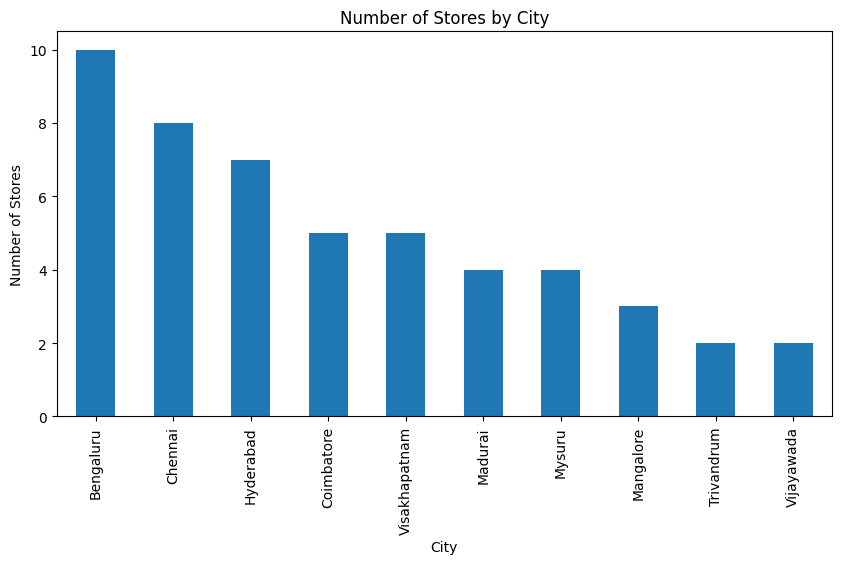

In [20]:
#Count stores in each city
city_store_count = df_store.groupby('city')['store_id'].nunique().sort_values(ascending=False)

print(city_store_count)

# Create the bar chart - Plot

city_store_count.plot(
    kind='bar',
    figsize=(10, 5),
    title='Number of Stores by City',
    xlabel='City',
    ylabel='Number of Stores'
)

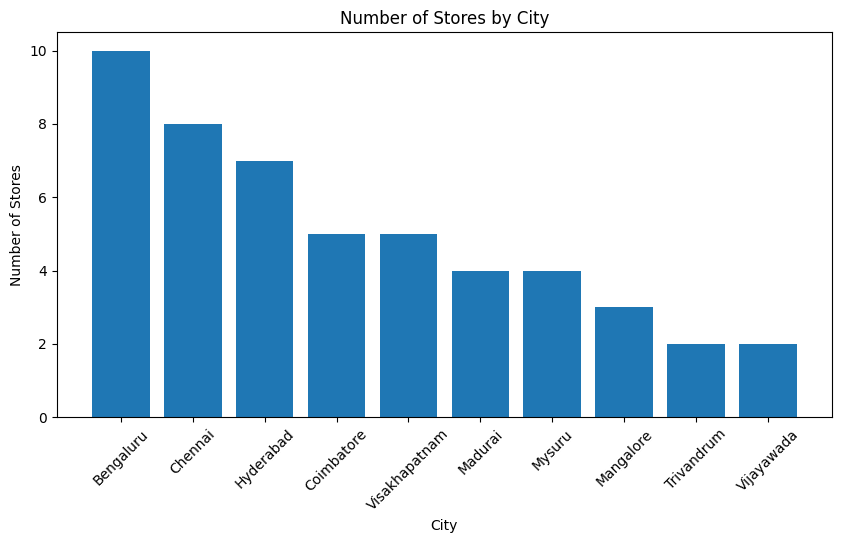

In [21]:
# Create the bar chart - Matplotlib

import matplotlib.pyplot as plt

city_store_count = df_store.groupby('city')['store_id'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(city_store_count.index, city_store_count.values)

plt.title('Number of Stores by City')
plt.xlabel('City')
plt.ylabel('Number of Stores')
plt.xticks(rotation=45)

plt.show()

Bengaluru has the highest number of stores with 10 stores. Chennai has 8 stores, while Hyderabad has 7 stores. Therefore, Bengaluru has 2 more stores than Chennai and 3 more stores than Hyderabad. This shows that AtliQ Mart has a stronger store presence in Bengaluru compared with these two cities.

Analyze the total quantity sold after promotion for the Sankranti campaign across different product categories. What percentage does each category contribute to the overall sales, and what insights can be drawn from these contributions? (Hint: Use a pie chart to visualize percentage contribution of each category to the overall sales)

category
Combo1                12411
Grocery & Staples    177724
Home Appliances       35610
Home Care             16894
Personal Care          9430
Name: quantity_sold(after_promo), dtype: int64
category
Combo1                4.92
Grocery & Staples    70.51
Home Appliances      14.13
Home Care             6.70
Personal Care         3.74
Name: quantity_sold(after_promo), dtype: float64


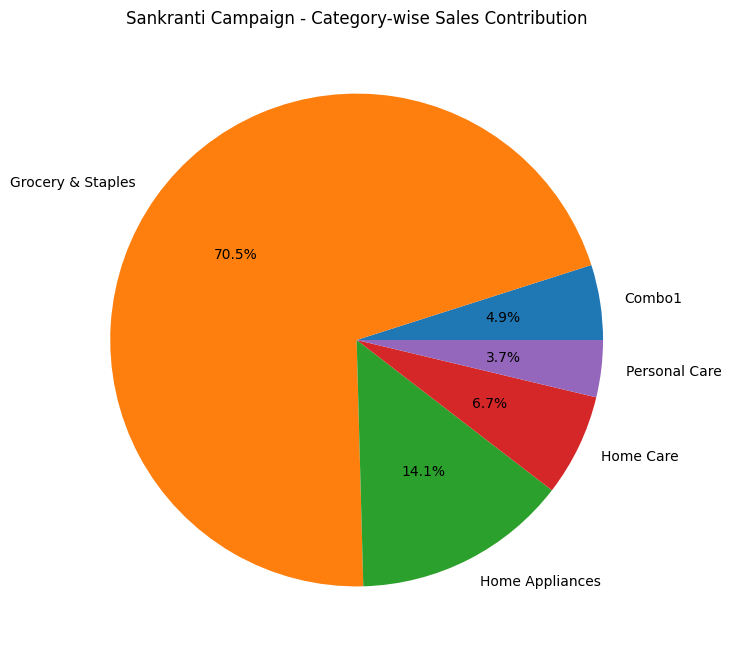

In [22]:
# Filter Sankranti campaign

df_sankranti = df_events[
    df_events['campaign_id'] == 'CAMP_SAN_01'
].copy()

df_sankranti = pd.merge(df_sankranti, df_dim_products, on='product_code', how='left')

# Calculate total quantity sold after promotion by category

# df_sankranti.head()
category_sales = df_sankranti.groupby('category')['quantity_sold(after_promo)'].sum()

print(category_sales)

# Calculate percentage contribution
category_percentage = (category_sales / category_sales.sum() * 100).round(2)

print(category_percentage)

# Create the pie chart

import matplotlib.pyplot as plt

category_percentage.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8, 8),
    title='Sankranti Campaign - Category-wise Sales Contribution'
)

plt.ylabel('')
plt.show()

The category with the largest percentage contributes the most to total Sankranti sales after promotion. A category with a small percentage contributes relatively less to overall sales.

### Examine the correlation between base price (after the promotion) and sales quantities (after the promotion). What insights can be drawn regarding the relationship between base price and sales quantities after the promotion? (Hint: Use heatmap to get the correlation)

Display correlation


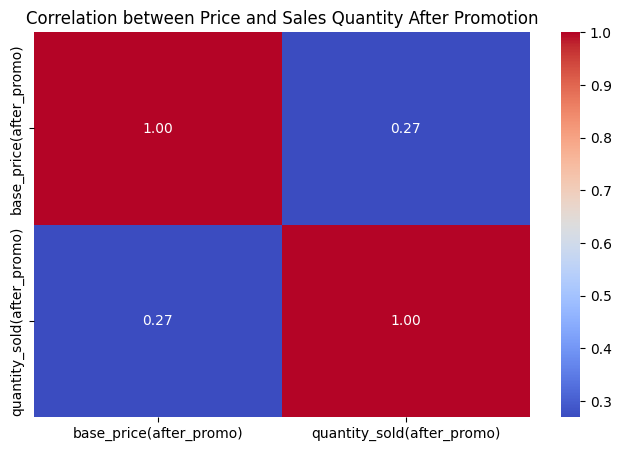

In [23]:
# Select the two columns
df_corr = df_events[ ['base_price(after_promo)', 'quantity_sold(after_promo)']]

# Calculate correlation
correlation = df_corr.corr()
print("Display correlation")
correlation

# Create the heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation between Price and Sales Quantity After Promotion')
plt.show()

### Analyze the distribution of quantity sold before the promotion for each product category (Grocery & Staples, Home Care, Personal Care, Home Appliances,etc.). What patterns or trends do you observe across these categories, and how could these insights inform future promotional strategies? (Hint: Use individual histograms to visualize the distribution)

Category


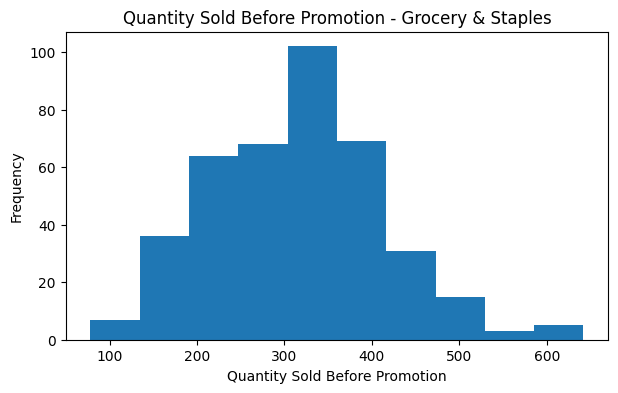

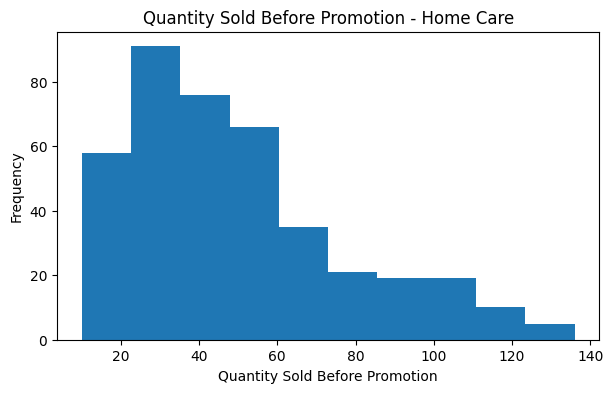

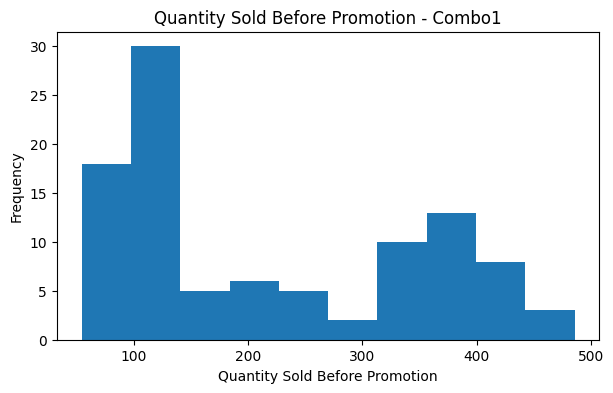

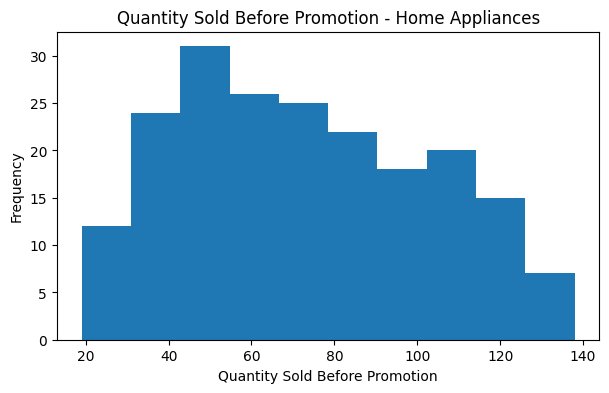

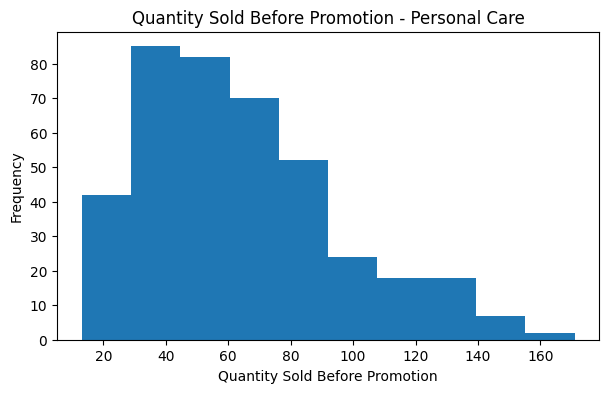

                   count     mean  median   min    max
category                                              
Combo1               100  217.300   147.0  54.0  486.0
Grocery & Staples    400  314.790   317.0  78.0  642.0
Home Appliances      200   73.280    72.0  19.0  138.0
Home Care            400   49.585    43.0  10.0  136.0
Personal Care        400   63.785    58.0  13.0  171.0


In [24]:
# Check the categories

df_category= df_events.copy()

df_category = pd.merge(df_category, df_dim_products, on='product_code', how='left')
print('Category')
df_category['category'].unique()

# Create individual histograms
import matplotlib.pyplot as plt

categories = df_category['category'].unique()

for category in categories:
    
    data = df_category[
        df_category['category'] == category
    ]['quantity_sold(before_promo)']
    
    plt.figure(figsize=(7, 4))
    
    plt.hist(data, bins=10)
    
    plt.title(f'Quantity Sold Before Promotion - {category}')
    plt.xlabel('Quantity Sold Before Promotion')
    plt.ylabel('Frequency')
    
    plt.show()



    category_summary = df_category.groupby('category')[
    'quantity_sold(before_promo)'
].agg(['count', 'mean', 'median', 'min', 'max'])

print(category_summary)

Assignment-style conclusion

The histograms show that the distribution of quantity sold before promotion varies across product categories. High-volume categories tend to have greater sales quantities, while categories such as Home Appliances may have lower or more dispersed sales volumes. Some categories may also show right-skewed distributions, indicating that a small number of products or stores generate exceptionally high sales. These insights can help design category-specific promotional strategies, rather than applying the same discount or promotion to every category. High-demand categories can focus on basket expansion and cross-selling, while lower-demand categories may benefit from targeted discounts and product-specific promotions.

Question - Analyze the incremental sold units percentage (ISU%) across various cities. Identify the city with the highest ISU% after the promotion and the city with the smallest change. What trends can be observed about the effectiveness of promotions in driving sales across these cities? (Hint: Use a line chart to visualize the ISU% comparison across cities)

City ISU
Highest Isu


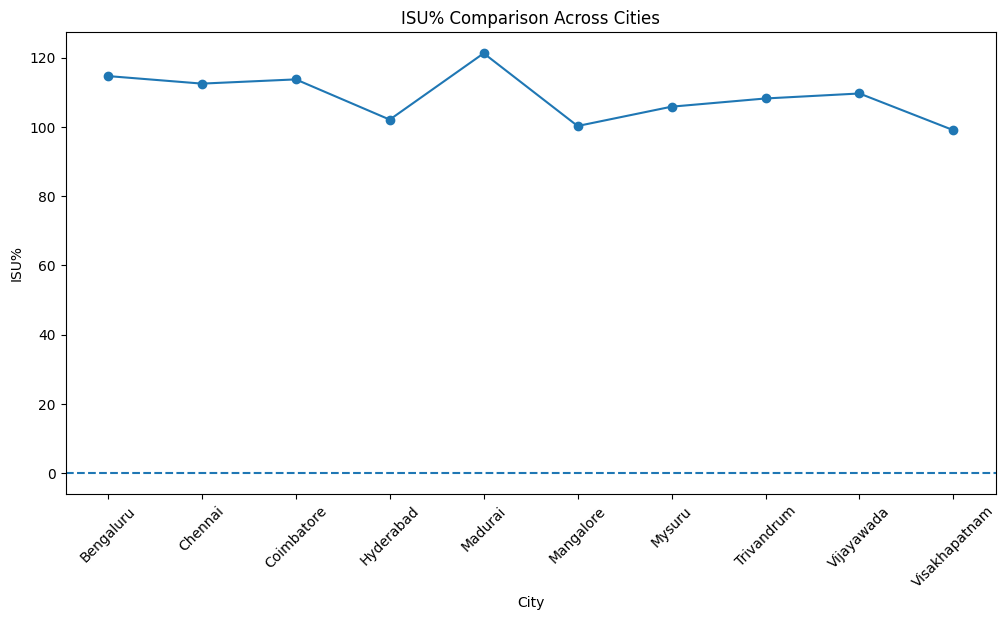

In [25]:
# # Calculate ISU% for each city

# df_events.head()
# df_store.head()

df_cityselldata = pd.merge(df_events, df_store, on='store_id', how='left')
city_isu = df_cityselldata.groupby('city').agg(
    quantity_before=('quantity_sold(before_promo)', 'sum'),
    quantity_after=('quantity_sold(after_promo)', 'sum')
).reset_index()

city_isu['ISU%'] = (
    (city_isu['quantity_after'] - city_isu['quantity_before'])
    / city_isu['quantity_before']
) * 100

city_isu['ISU%'] = city_isu['ISU%'].round(2)

print("City ISU")
city_isu

# Find the city with highest ISU%

highest_isu = city_isu.loc[[
    city_isu['ISU%'].idxmax()
]]

print('Highest Isu')
highest_isu

# Line chart
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    city_isu['city'],
    city_isu['ISU%'],
    marker='o'
)

plt.title('ISU% Comparison Across Cities')
plt.xlabel('City')
plt.ylabel('ISU%')
plt.xticks(rotation=45)

plt.axhline(0, linestyle='--')

plt.show()

Assignment-style conclusion

The ISU% comparison shows that the effectiveness of promotions varies across cities. The city with the highest ISU% experienced the greatest increase in units sold after the promotion, indicating that promotions were highly effective there. The city with the smallest ISU% showed the least improvement in sales, suggesting that promotions had limited effectiveness in that market. Therefore, promotional strategies should be adapted according to city-level customer response rather than applying the same strategy across all cities.

 Question - Analyze the relationship between incremental revenue and incremental sold units
for different promotion types in Hyderabad. Which promotion type led to the
highest incremental sold units, and which one generated the highest incremental
revenue? What insights can you draw from the balance between the two metrics
for this city? 

In [26]:
# Filter Hyderabad 
df_hyderabad = df_cityselldata[
    df_cityselldata['city'] == 'Hyderabad'
].copy()

# Calculate incremental units and revenue

df_hyderabad['incremental_units'] = (
    df_hyderabad['quantity_sold(after_promo)']
    - df_hyderabad['quantity_sold(before_promo)']
)

df_hyderabad['revenue_before'] = (
    df_hyderabad['quantity_sold(before_promo)']
    * df_hyderabad['base_price(before_promo)']
)

df_hyderabad['revenue_after'] = (
    df_hyderabad['quantity_sold(after_promo)']
    * df_hyderabad['base_price(after_promo)']
)

df_hyderabad['incremental_revenue'] = (
    df_hyderabad['revenue_after']
    - df_hyderabad['revenue_before']
)

# Group by promotion type
result = df_hyderabad.groupby('promo_type').agg(
    incremental_units=('incremental_units', 'sum'),
    incremental_revenue=('incremental_revenue', 'sum')
).reset_index()

print('Group by Promotion Type')
result

# Find the highest incremental sold units
highest_units = result.loc[[
    result['incremental_units'].idxmax()
]]

print('Find the highest incremental sold units',highest_units)


# Find the highest incremental revenue
highest_revenue = result.loc[[
    result['incremental_revenue'].idxmax()
]]


print('Highest incremental sold units',highest_revenue)


Group by Promotion Type
Find the highest incremental sold units   promo_type  incremental_units  incremental_revenue
4      BOGOF            24168.0            3182420.0
Highest incremental sold units      promo_type  incremental_units  incremental_revenue
3  500 Cashback             5845.0           12866500.0


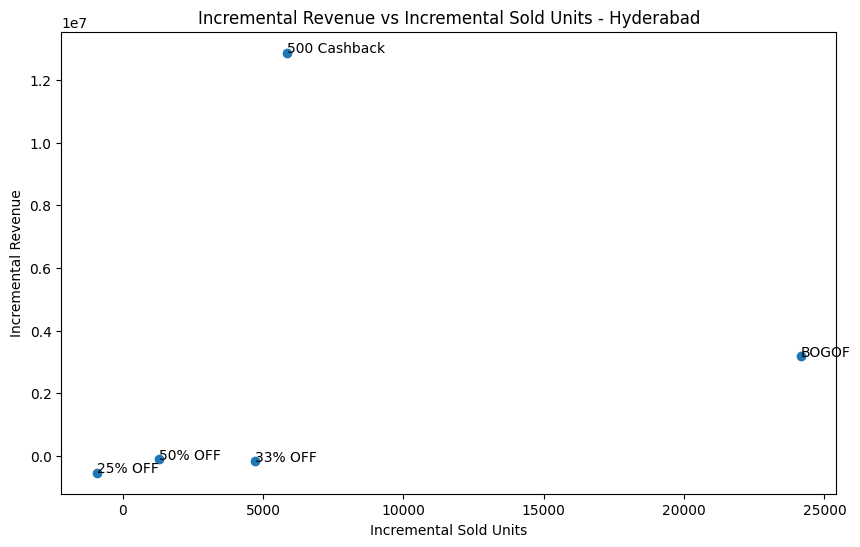

In [27]:
#Create the scatter plot

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(
    result['incremental_units'],
    result['incremental_revenue']
)

for i in range(len(result)):
    plt.annotate(
        result.loc[i, 'promo_type'],
        (
            result.loc[i, 'incremental_units'],
            result.loc[i, 'incremental_revenue']
        )
    )

plt.xlabel('Incremental Sold Units')
plt.ylabel('Incremental Revenue')
plt.title('Incremental Revenue vs Incremental Sold Units - Hyderabad')

plt.show()

Assignment-style conclusion

In Hyderabad, the promotion type with the highest incremental sold units was the one that generated the largest increase in product volume. The promotion type with the highest incremental revenue was the one that generated the greatest additional sales value. Comparing these two metrics helps identify whether a promotion is primarily effective at driving volume or revenue. The ideal promotion would perform strongly on both metrics, indicating that it increases sales quantities while also generating substantial additional revenue.

Question - Analyze the revenue before and after promotions across different product
categories in Bengaluru. What trends can be identified in the performance of
each category, and how did promotions impact overall revenue in the city?
(Hint: Use a vertical bar chart to compare the revenue before and after promotions)

In [28]:
# Filter Bengaluru

df_cityselldata_bengaluru = pd.merge(df_events, df_store, on='store_id', how='left')
df_bengaluru  = df_cityselldata_bengaluru[
    df_cityselldata_bengaluru['city'] == 'Hyderabad'
].copy()

df_bengaluru = pd.merge(df_bengaluru, df_dim_products, on='product_code', how='left')

# Calculate revenue before and after promotion
df_bengaluru['revenue_before'] = (
    df_bengaluru['quantity_sold(before_promo)']
    * df_bengaluru['base_price(before_promo)']
)

df_bengaluru['revenue_after'] = (
    df_bengaluru['quantity_sold(after_promo)']
    * df_bengaluru['base_price(after_promo)']
)

#Calculate category-wise revenue

df_bengaluru.head()

category_revenue = df_bengaluru.groupby('category').agg(
    revenue_before=('revenue_before', 'sum'),
    revenue_after=('revenue_after', 'sum')
).reset_index()

print('category-wise revenue')
category_revenue

# Calculate revenue change
category_revenue['incremental_revenue'] = (
    category_revenue['revenue_after']
    - category_revenue['revenue_before']
)

print('Calculate revenue change')
category_revenue


category-wise revenue
Calculate revenue change


,category,revenue_before,revenue_after,incremental_revenue
0,Combo1,10476000.0,23342500,12866500.0
1,Grocery & Staples,8729232.0,9458423,729191.0
2,Home Appliances,1526770.0,2705975,1179205.0
3,Home Care,1552275.0,2127799,575524.0
4,Personal Care,408964.0,274960,-134004.0


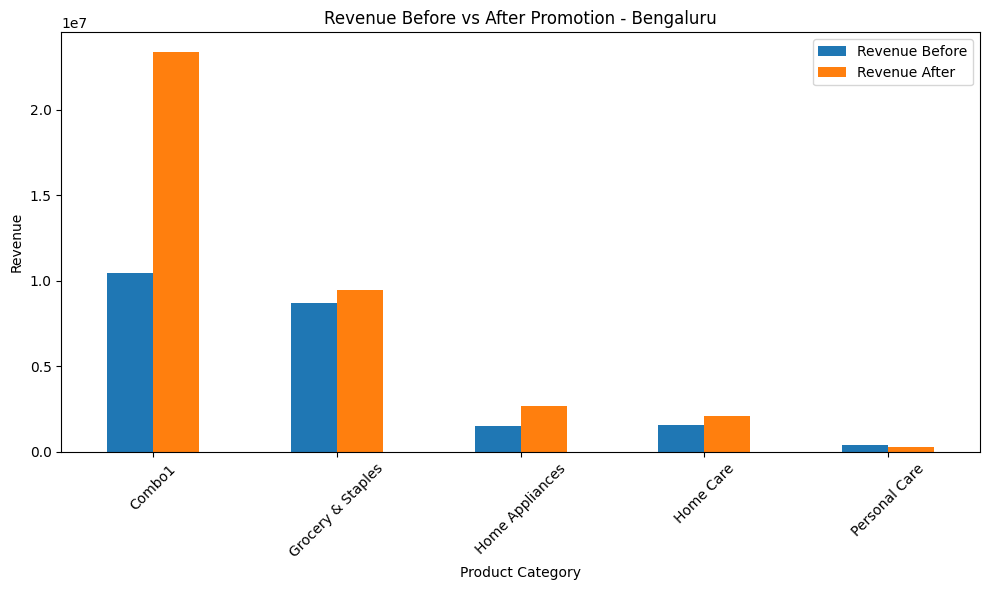

In [29]:
# Vertical bar chart
import matplotlib.pyplot as plt

category_revenue.plot(
    x='category',
    y=['revenue_before', 'revenue_after'],
    kind='bar',
    figsize=(10, 6)
)

plt.xlabel('Product Category')
plt.ylabel('Revenue')
plt.title('Revenue Before vs After Promotion - Bengaluru')
plt.xticks(rotation=45)
plt.legend(['Revenue Before', 'Revenue After'])
plt.tight_layout()
plt.show()

How to interpret the chart
After bar higher than Before bar → promotion successfully increased revenue.
After bar lower than Before bar → promotion reduced revenue.
The category with the largest gap between after and before has the greatest revenue impact.
If most categories have higher after-promotion revenue, promotions had a positive overall impact on Bengaluru revenue.
If some categories decline, those promotions may have increased sales volume but reduced revenue because of the discount.
Assignment-style conclusion

The comparison of revenue before and after promotions across product categories in Bengaluru helps identify which categories benefited most from promotional campaigns. Categories where post-promotion revenue is higher than pre-promotion revenue indicate successful promotions, while categories with lower post-promotion revenue indicate that discounts may have reduced revenue. Overall, the difference between total revenue before and after promotions shows whether promotions had a positive or negative impact on Bengaluru's revenue.